# 1-D test of the MOBO utils (`utils.mobo`)

A small, fully self-contained sandbox for the **same GP surrogate + Bayesian-optimization
machinery** used in `experiment02_pdo_analysis.ipynb`, reduced to **one input factor** so
every piece can be drawn and reasoned about.

The acquisition is `qLogNEHVI`, which is inherently *multi-objective* (needs ≥ 2 outputs),
so this is a **1-input / 2-objective** test, not a single-objective one. We use a known
ground truth with two **conflicting** objectives so the Pareto front, the GP fit, the
effect of the observation noise (`y_var` / `train_Yvar`), and the proposed candidates are
all interpretable.

Everything routes through `utils.mobo`:
`encode_unit` → `variance_of_mean_by_group` → `fit_gp(..., Yvar=...)` → `pareto_front` →
`propose_candidates`. Swap in your own `f1`/`f2` (cell *Ground truth*) to test other shapes.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
if REPO_ROOT not in sys.path:                 # make the repo-root `utils` package importable
    sys.path.insert(0, REPO_ROOT)
import utils.mobo as mobo

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
tkw = {'dtype': torch.double}
plt.rcParams['figure.dpi'] = 120
print('utils.mobo loaded from', os.path.dirname(mobo.__file__))

utils.mobo loaded from /data/zhq7531/IDEAL/DMREF/repository_dmref/utils


## 1. Problem definition (one engineering factor)

To mirror the real pipeline we define a single **engineering-unit** factor and use
`mobo.encode_unit` / `mobo.decode_unit` to move between engineering units and the unit
cube `[0, 1]` the GP works in. Here the factor is an anneal temperature on `(200, 800) °C`.

Two **conflicting** objectives (both written in botorch's *maximize* convention) are defined
on the normalized coordinate `u ∈ [0, 1]`:

* `f1` peaks low (`u ≈ 0.25`)
* `f2` peaks high (`u ≈ 0.75`)

so moving toward one objective's optimum hurts the other — that conflict is exactly what
produces a non-trivial Pareto front.

In [2]:
FACTOR   = 'Anneal Temp (°C)'
FACTORS  = [FACTOR]
BOUNDS   = {FACTOR: (200.0, 800.0)}       # engineering range
CATS     = {}                              # no categorical factors in this test
DECIMALS = {FACTOR: 1}

# --- Ground truth (edit these to test other shapes) -----------------------------------
# Defined on the NORMALIZED coordinate u in [0, 1]; both objectives are MAXIMIZED.
def f1_true(u):  # peaks near u = 0.25
    return np.exp(-((u - 0.25) / 0.18) ** 2)
def f2_true(u):  # peaks near u = 0.75
    return np.exp(-((u - 0.75) / 0.18) ** 2)

OBJ_NAMES   = ['f1 (max)', 'f2 (max)']
NOISE_STD   = 0.05      # per-replicate measurement noise on each objective
N_COND      = 3         # INITIAL samples (the sequential BO loop in §6 grows this)
K_REPS      = 3         # replicates per condition -> drives the SEM^2 noise (y_var)

def encode(T):   # engineering -> unit cube
    return mobo.encode_unit(pd.DataFrame({FACTOR: np.atleast_1d(T)}), FACTORS, BOUNDS, CATS)
def decode(U):   # unit cube -> engineering
    return mobo.decode_unit(U, FACTORS, BOUNDS, CATS, DECIMALS)

## 2. Sample noisy, replicated data

We pick `N_COND` temperatures, take `K_REPS` noisy replicate measurements of each objective
at each, then collapse to per-condition **means** (the GP targets) and per-condition
**SEM² = replicate_var / n** (the `y_var` fed to the GP) — using the very same helper the
real notebook uses, `mobo.variance_of_mean_by_group`.

In [3]:
# Sampled conditions (spread across the range + small jitter), engineering units.
T_cond = np.linspace(220, 780, N_COND) + np.random.uniform(-15, 15, N_COND)
u_cond = encode(T_cond).ravel()

# Long (replicate-level) table: one row per replicate, like the raw experimental data.
rows = []
for cid, (T, u) in enumerate(zip(T_cond, u_cond), start=1):
    for _ in range(K_REPS):
        rows.append({'cond': cid, FACTOR: T,
                     'f1': f1_true(u) + np.random.normal(0, NOISE_STD),
                     'f2': f2_true(u) + np.random.normal(0, NOISE_STD)})
reps = pd.DataFrame(rows)

# Per-condition means (GP targets) ...
cond = (reps.groupby('cond')
             .agg({FACTOR: 'first', 'f1': 'mean', 'f2': 'mean'})
             .reset_index())
# ... and per-condition SEM^2 (observation noise / y_var) via the shared helper.
sem2_f1 = mobo.variance_of_mean_by_group(reps, 'cond', 'f1')
sem2_f2 = mobo.variance_of_mean_by_group(reps, 'cond', 'f2')

X    = torch.tensor(encode(cond[FACTOR].values), **tkw)                     # (n, 1)
Y    = torch.tensor(np.c_[cond['f1'].values, cond['f2'].values], **tkw)     # (n, 2)
Yvar = torch.tensor(np.c_[sem2_f1.reindex(cond['cond']).values,
                          sem2_f2.reindex(cond['cond']).values], **tkw)     # (n, 2)

print(f'{N_COND} conditions x {K_REPS} replicates')
print(f'median SEM^2  f1={np.median(sem2_f1.values):.4g}  f2={np.median(sem2_f2.values):.4g}'
      f'   (expected ~ {NOISE_STD**2/K_REPS:.4g})')
cond.round(3)

3 conditions x 3 replicates
median SEM^2  f1=0.0001556  f2=0.0005501   (expected ~ 0.0008333)


,cond,Anneal Temp (°C),f1,f2
0,1,207.289,0.207,0.048
1,2,508.398,0.105,0.194
2,3,778.152,0.028,0.239


## 3. Fit the GP with observation noise (`y_var`) and view the 1-D fit

`mobo.fit_gp(X, Y, Yvar=Yvar)` builds a fixed-noise `SingleTaskGP` (one independent GP per
objective). Because the input is 1-D we can plot the full posterior: the predicted mean and
a ±2σ band over a dense temperature grid, with the true curve and the noisy training means
(±1 SEM error bars) overlaid.

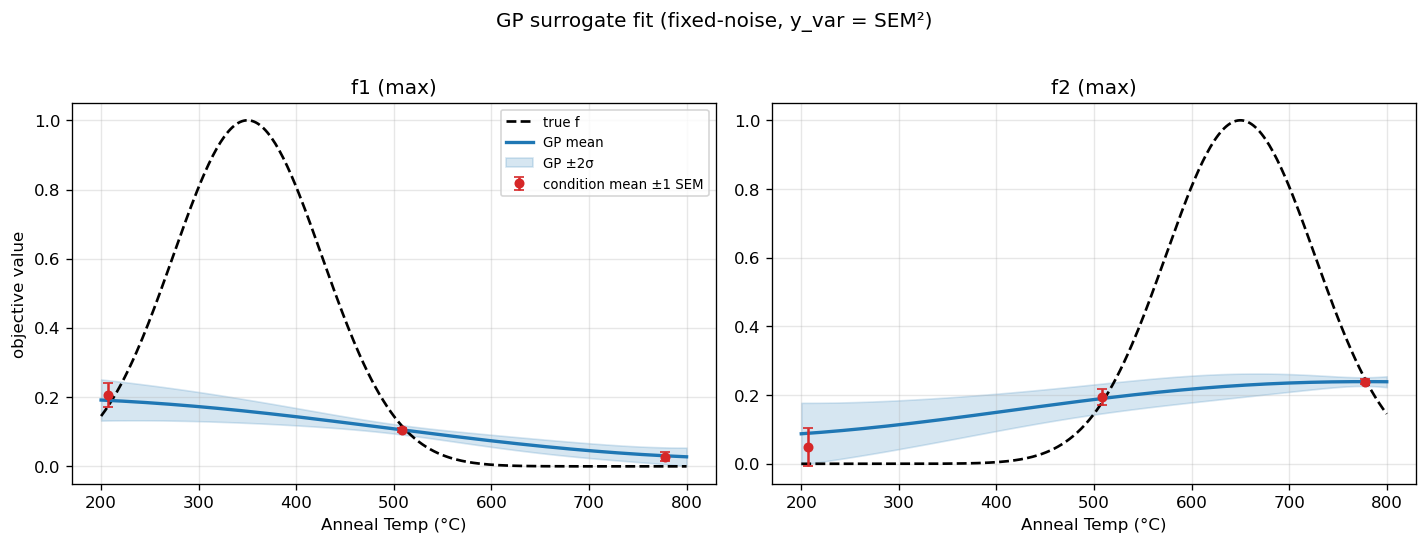

In [4]:
# Fit with per-point SEM^2 as observation noise.
model = mobo.fit_gp(X, Y, Yvar=Yvar)

# Dense grid for plotting (engineering units -> normalized -> posterior).
T_grid = np.linspace(200, 800, 300)
U_grid = torch.tensor(encode(T_grid), **tkw)
post   = model.posterior(U_grid)
mean   = post.mean.detach().numpy()                 # (300, 2)
sd     = post.variance.sqrt().detach().numpy()      # (300, 2)
u_grid = U_grid.numpy().ravel()
truth  = [f1_true(u_grid), f2_true(u_grid)]
sem    = [sem2_f1.reindex(cond['cond']).values ** 0.5,
          sem2_f2.reindex(cond['cond']).values ** 0.5]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(T_grid, truth[k], 'k--', lw=1.6, label='true f', zorder=2)
    ax.plot(T_grid, mean[:, k], color='#1f77b4', lw=2, label='GP mean', zorder=3)
    ax.fill_between(T_grid, mean[:, k] - 2*sd[:, k], mean[:, k] + 2*sd[:, k],
                    color='#1f77b4', alpha=0.18, label='GP ±2σ', zorder=1)
    ax.errorbar(cond[FACTOR], Y[:, k].numpy(), yerr=sem[k], fmt='o', color='#d62728',
                ms=5, capsize=3, label='condition mean ±1 SEM', zorder=4)
    ax.set_title(OBJ_NAMES[k]); ax.set_xlabel(FACTOR); ax.grid(alpha=0.3)
axes[0].set_ylabel('objective value'); axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('GP surrogate fit (fixed-noise, y_var = SEM²)', y=1.02)
plt.tight_layout(); plt.show()

### 3a. What does `y_var` actually change?

The fixed-noise model is told *how trustworthy each averaged point is* (its SEM²) instead of
inferring one global noise level. Below we refit the **same data without** `Yvar`
(`mobo.fit_gp(X, Y)`, inferred homoskedastic noise) and overlay the two ±2σ bands for `f1`.
With `y_var` the band is pinned tighter where replicates agreed and the mean honors the
known measurement noise rather than chasing every point.

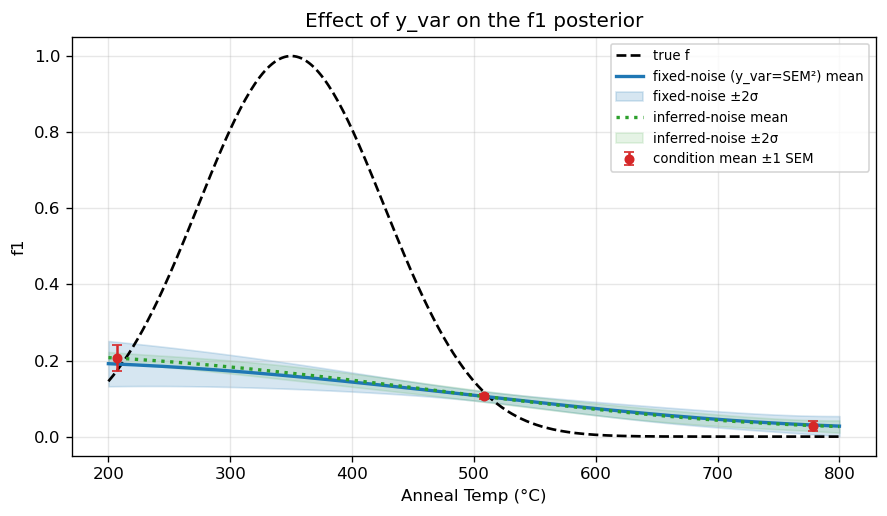

In [5]:
model_inf = mobo.fit_gp(X, Y)                      # Yvar=None -> inferred noise
mean_i = model_inf.posterior(U_grid).mean.detach().numpy()
sd_i   = model_inf.posterior(U_grid).variance.sqrt().detach().numpy()

k = 0  # f1
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(T_grid, truth[k], 'k--', lw=1.6, label='true f')
ax.plot(T_grid, mean[:, k],  color='#1f77b4', lw=2, label='fixed-noise (y_var=SEM²) mean')
ax.fill_between(T_grid, mean[:, k]-2*sd[:, k],  mean[:, k]+2*sd[:, k],
                color='#1f77b4', alpha=0.18, label='fixed-noise ±2σ')
ax.plot(T_grid, mean_i[:, k], color='#2ca02c', lw=2, ls=':', label='inferred-noise mean')
ax.fill_between(T_grid, mean_i[:, k]-2*sd_i[:, k], mean_i[:, k]+2*sd_i[:, k],
                color='#2ca02c', alpha=0.12, label='inferred-noise ±2σ')
ax.errorbar(cond[FACTOR], Y[:, k].numpy(), yerr=sem[k], fmt='o', color='#d62728',
            ms=5, capsize=3, label='condition mean ±1 SEM')
ax.set_title('Effect of y_var on the f1 posterior'); ax.set_xlabel(FACTOR)
ax.set_ylabel('f1'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Observed Pareto front + reference point

`mobo.pareto_front(Y)` returns the non-dominated mask, the dominated hypervolume, and the
reference point (a margin below the worst value on each objective). In objective space the
conflicting design pushes the optimum toward the **upper-right** corner.

Pareto-optimal conditions: [1, 2, 3]
Reference point [f1 (max), f2 (max)]: [0.01, 0.029]
Observed hypervolume: 0.0184


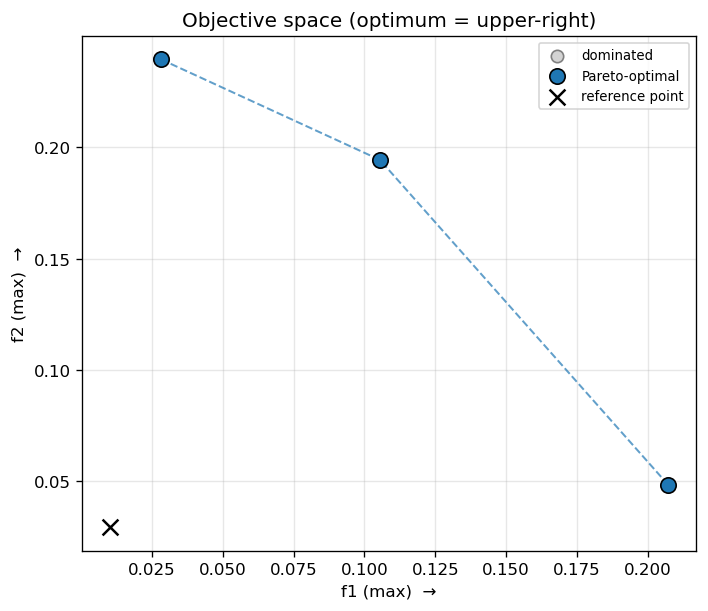

In [6]:
pareto_mask, obs_hv, ref_point = mobo.pareto_front(Y)
pm = pareto_mask.numpy()
print(f'Pareto-optimal conditions: {cond.loc[pm, "cond"].tolist()}')
print(f'Reference point [{OBJ_NAMES[0]}, {OBJ_NAMES[1]}]: {np.round(ref_point.numpy(),3).tolist()}')
print(f'Observed hypervolume: {obs_hv:.4f}')

fig, ax = plt.subplots(figsize=(6, 5.2))
ax.scatter(Y[~pm,0], Y[~pm,1], c='lightgray', edgecolor='gray', s=55, label='dominated')
ax.scatter(Y[pm,0],  Y[pm,1],  c='#1f77b4', edgecolor='k', s=85, zorder=3, label='Pareto-optimal')
pf = cond.loc[pm].assign(f1=Y[pm,0].numpy(), f2=Y[pm,1].numpy()).sort_values('f1')
ax.plot(pf['f1'], pf['f2'], color='#1f77b4', ls='--', lw=1.2, alpha=0.7)
ax.scatter(*ref_point.numpy(), marker='x', s=90, color='k', label='reference point')
ax.set_xlabel(OBJ_NAMES[0]+'  →'); ax.set_ylabel(OBJ_NAMES[1]+'  →')
ax.set_title('Objective space (optimum = upper-right)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Propose candidates and visualize the acquisition

`mobo.propose_candidates(...)` with `fixed_features_list=None` runs a plain continuous
`optimize_acqf` on the 1-D box — exactly the path a no-categorical test takes. Because the
search is 1-D we can also draw the **acquisition landscape**: evaluate the returned qLogNEHVI
object on a single-point grid `(G, 1, 1)` and mark where the proposals land. The batch is
chosen *jointly*, so the `q` points spread out for diversity rather than all stacking on the
single global maximum.

Joint qLogNEHVI (q=3): -5.4521
  C1: Anneal Temp (°C)=  423.5  pred f1=0.136  f2=0.159  indiv acq=-6.1862
  C2: Anneal Temp (°C)=  333.6  pred f1=0.164  f2=0.125  indiv acq=-6.1889
  C3: Anneal Temp (°C)=  611.9  pred f1=0.070  f2=0.220  indiv acq=-6.7148


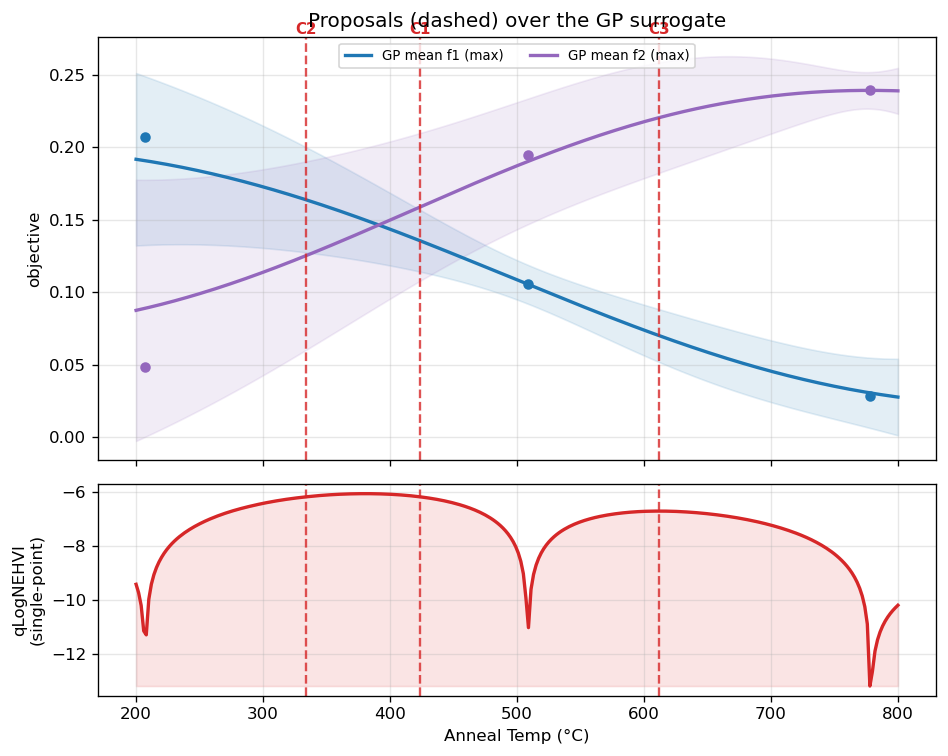

In [7]:
Q = 3
bounds = torch.stack([torch.zeros(1, **tkw), torch.ones(1, **tkw)])   # (2, 1) unit box
candidates, joint, indiv, acq = mobo.propose_candidates(
    model, ref_point, X_baseline=X, bounds=bounds, q=Q,
    fixed_features_list=None, num_restarts=20, raw_samples=256, seed=SEED)

order = np.argsort(-indiv); candidates = candidates[order]; indiv = indiv[order]
cand_T = decode(candidates.detach().numpy())[FACTOR].values
cand_mean = model.posterior(candidates).mean.detach().numpy()
print(f'Joint qLogNEHVI (q={Q}): {joint:.4f}')
for i in range(Q):
    print(f'  C{i+1}: {FACTOR}={cand_T[i]:7.1f}  pred f1={cand_mean[i,0]:.3f}  '
          f'f2={cand_mean[i,1]:.3f}  indiv acq={indiv[i]:.4f}')

# Acquisition landscape over the 1-D grid (single-point EHVI at each temperature).
acq_grid = acq(U_grid.reshape(-1, 1, 1)).detach().numpy()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6.4), sharex=True,
                             gridspec_kw={'height_ratios':[2,1]})
# top: both GP means + proposals
for k, c in enumerate(['#1f77b4', '#9467bd']):
    a1.plot(T_grid, mean[:, k], color=c, lw=2, label=f'GP mean {OBJ_NAMES[k]}')
    a1.fill_between(T_grid, mean[:,k]-2*sd[:,k], mean[:,k]+2*sd[:,k], color=c, alpha=0.12)
a1.scatter(cond[FACTOR], Y[:,0].numpy(), c='#1f77b4', s=28, zorder=4)
a1.scatter(cond[FACTOR], Y[:,1].numpy(), c='#9467bd', s=28, zorder=4)
for i in range(Q):
    a1.axvline(cand_T[i], color='#d62728', ls='--', lw=1.4, alpha=0.8)
    a1.annotate(f'C{i+1}', (cand_T[i], a1.get_ylim()[1]), color='#d62728',
                fontweight='bold', ha='center', va='bottom', fontsize=9)
a1.set_ylabel('objective'); a1.legend(fontsize=8, loc='upper center', ncol=2); a1.grid(alpha=0.3)
a1.set_title('Proposals (dashed) over the GP surrogate')
# bottom: acquisition landscape
a2.plot(T_grid, acq_grid, color='#d62728', lw=2)
a2.fill_between(T_grid, acq_grid.min(), acq_grid, color='#d62728', alpha=0.12)
for i in range(Q):
    a2.axvline(cand_T[i], color='#d62728', ls='--', lw=1.4, alpha=0.8)
a2.set_ylabel('qLogNEHVI\n(single-point)'); a2.set_xlabel(FACTOR); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5a. Proposals in objective space

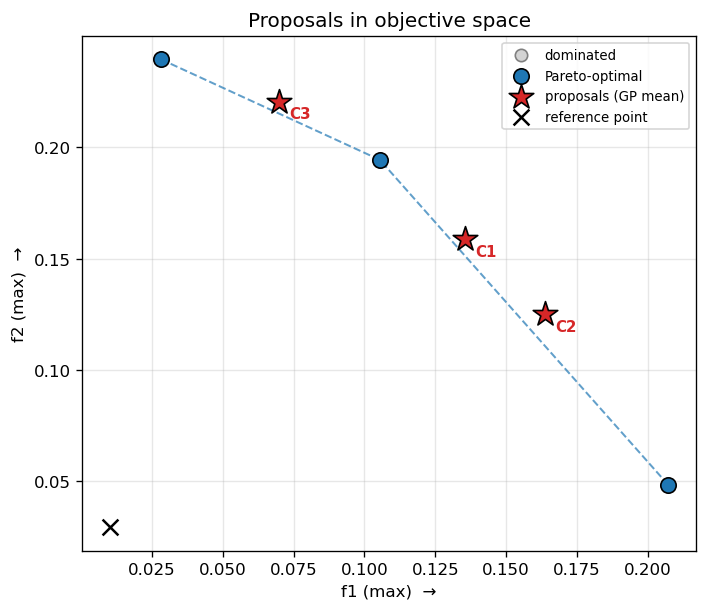

In [8]:
fig, ax = plt.subplots(figsize=(6, 5.2))
ax.scatter(Y[~pm,0], Y[~pm,1], c='lightgray', edgecolor='gray', s=55, label='dominated')
ax.scatter(Y[pm,0],  Y[pm,1],  c='#1f77b4', edgecolor='k', s=85, zorder=3, label='Pareto-optimal')
ax.plot(pf['f1'], pf['f2'], color='#1f77b4', ls='--', lw=1.2, alpha=0.7)
ax.scatter(cand_mean[:,0], cand_mean[:,1], marker='*', s=240, color='#d62728',
           edgecolor='k', zorder=5, label='proposals (GP mean)')
for i in range(Q):
    ax.annotate(f'C{i+1}', (cand_mean[i,0], cand_mean[i,1]), color='#d62728',
                fontweight='bold', fontsize=9, xytext=(6,-10), textcoords='offset points')
ax.scatter(*ref_point.numpy(), marker='x', s=90, color='k', label='reference point')
ax.set_xlabel(OBJ_NAMES[0]+'  →'); ax.set_ylabel(OBJ_NAMES[1]+'  →')
ax.set_title('Proposals in objective space'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Sequential Bayesian-optimization loop (10 iterations) — animated

Now the payoff: start from just the **3 initial samples** above and let BO drive the
sampling. Each iteration we (1) refit the GP with `y_var`, (2) compute the Pareto front +
**hypervolume** against a *fixed* reference point, (3) propose **one** new temperature with
`mobo.propose_candidates(q=1)`, then (4) "measure" it (sample `K_REPS` noisy replicates of
the ground truth) and add it to the dataset.

The reference point is held fixed across iterations so the hypervolume is comparable frame to
frame (adding data can only grow it). The movie shows all four 1-D views at once — the two GP
posteriors, the acquisition landscape (red dashed line = where it sampled next), and the
objective-space Pareto front with the proposal as a red ★.

In [9]:
from matplotlib import animation
from IPython.display import HTML

REF      = torch.tensor([-0.15, -0.15], **tkw)   # FIXED reference point -> comparable hypervolume
N_ITERS  = 10
OUT_DIR  = os.path.join(REPO_ROOT, 'output', 'mobo_1d_test')
os.makedirs(OUT_DIR, exist_ok=True)

bo_reps  = reps.copy()                  # start from the 3 initial conditions (§2)
next_cid = int(bo_reps['cond'].max()) + 1
frames, n_hist, hv_hist = [], [], []

for t in range(N_ITERS):
    c  = bo_reps.groupby('cond').agg({FACTOR:'first','f1':'mean','f2':'mean'}).reset_index()
    s1 = mobo.variance_of_mean_by_group(bo_reps, 'cond', 'f1')
    s2 = mobo.variance_of_mean_by_group(bo_reps, 'cond', 'f2')
    Xb  = torch.tensor(encode(c[FACTOR].values), **tkw)
    Yb  = torch.tensor(np.c_[c['f1'].values, c['f2'].values], **tkw)
    Yvb = torch.tensor(np.c_[s1.reindex(c['cond']).values, s2.reindex(c['cond']).values], **tkw)

    m = mobo.fit_gp(Xb, Yb, Yvar=Yvb)                                   # refit with y_var
    mask, hv, _ = mobo.pareto_front(Yb, ref_point=REF)                  # front + hypervolume
    cand, _, _, acq = mobo.propose_candidates(                          # propose 1 point
        m, REF, X_baseline=Xb, bounds=bounds, q=1,
        fixed_features_list=None, num_restarts=20, raw_samples=256, seed=SEED + t)

    pg = m.posterior(U_grid)
    frames.append(dict(
        n=len(c), mean=pg.mean.detach().numpy(), sd=pg.variance.sqrt().detach().numpy(),
        acq=acq(U_grid.reshape(-1,1,1)).detach().numpy(),
        X_T=c[FACTOR].values, Y=Yb.numpy(), mask=mask.numpy(), hv=hv,
        xT=float(decode(cand.detach().numpy())[FACTOR].values[0]),
        pstar=m.posterior(cand).mean.detach().numpy().ravel()))
    n_hist.append(len(c)); hv_hist.append(hv)

    # "measure" the proposed temperature: K_REPS noisy replicates of the ground truth.
    u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])
    new = pd.DataFrame({'cond': next_cid, FACTOR: frames[-1]['xT'],
                        'f1': f1_true(u_eval) + np.random.normal(0, NOISE_STD, K_REPS),
                        'f2': f2_true(u_eval) + np.random.normal(0, NOISE_STD, K_REPS)})
    bo_reps = pd.concat([bo_reps, new], ignore_index=True); next_cid += 1

# hypervolume after the final measurement (the curve then has N_ITERS+1 points).
cF = bo_reps.groupby('cond').agg({'f1':'mean','f2':'mean'}).reset_index()
_, hvF, _ = mobo.pareto_front(torch.tensor(np.c_[cF['f1'], cF['f2']], **tkw), ref_point=REF)
n_hist.append(len(cF)); hv_hist.append(hvF)
print(f'Ran {N_ITERS} BO iterations: {n_hist[0]} -> {n_hist[-1]} observations')
print(f'Hypervolume {hv_hist[0]:.3f} -> {hv_hist[-1]:.3f}')

/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


...

/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


Ran 10 BO iterations: 3 -> 13 observations
Hypervolume 0.116 -> 0.367


/tmp/claude-1027/ipykernel_2329985/3281599413.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_eval = float(encode(decode(cand.detach().numpy())[FACTOR].values)[0])


In [10]:
# --- Build the animation (4 synchronized 1-D views per BO iteration) ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)
fig.set_dpi(90)
a_f1, a_f2, a_acq, a_obj = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

def draw(i):
    fr = frames[i]
    for ax in axes.ravel(): ax.clear()
    for ax, k, col, nm in [(a_f1,0,'#1f77b4','f1'), (a_f2,1,'#9467bd','f2')]:
        ax.plot(T_grid, truth[k], 'k--', lw=1.3, label='true f')
        ax.plot(T_grid, fr['mean'][:,k], color=col, lw=2, label='GP mean')
        ax.fill_between(T_grid, fr['mean'][:,k]-2*fr['sd'][:,k], fr['mean'][:,k]+2*fr['sd'][:,k],
                        color=col, alpha=0.18)
        ax.scatter(fr['X_T'], fr['Y'][:,k], c=col, edgecolor='k', s=40, zorder=4)
        ax.axvline(fr['xT'], color='#d62728', ls='--', lw=1.5)
        ax.set_ylim(-0.3, 1.35); ax.set_title(f'GP surrogate — {nm}')
        ax.set_xlabel(FACTOR); ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='upper right')
    a_acq.plot(T_grid, fr['acq'], color='#d62728', lw=2)
    a_acq.fill_between(T_grid, np.min(fr['acq']), fr['acq'], color='#d62728', alpha=0.15)
    a_acq.axvline(fr['xT'], color='#d62728', ls='--', lw=1.6)
    a_acq.set_title('acquisition (qLogNEHVI) — next sample at ▼')
    a_acq.set_xlabel(FACTOR); a_acq.grid(alpha=0.3)
    a_acq.annotate('▼', (fr['xT'], np.max(fr['acq'])), color='#d62728', ha='center',
                   va='bottom', fontweight='bold')
    mask, Y = fr['mask'], fr['Y']
    a_obj.scatter(Y[~mask,0], Y[~mask,1], c='lightgray', edgecolor='gray', s=45, label='dominated')
    a_obj.scatter(Y[mask,0],  Y[mask,1],  c='#1f77b4', edgecolor='k', s=70, zorder=3, label='Pareto')
    a_obj.scatter(fr['pstar'][0], fr['pstar'][1], marker='*', s=260, color='#d62728',
                  edgecolor='k', zorder=5, label='proposal (GP mean)')
    a_obj.scatter(*REF.numpy(), marker='x', s=70, color='k', label='reference')
    a_obj.set_xlim(-0.25, 1.3); a_obj.set_ylim(-0.25, 1.3)
    a_obj.set_title('objective space'); a_obj.set_xlabel('f1'); a_obj.set_ylabel('f2')
    a_obj.grid(alpha=0.3); a_obj.legend(fontsize=7, loc='lower left')
    fig.suptitle(f'BO iteration {i+1}/{len(frames)}   |   n = {fr["n"]} observations'
                 f'   |   hypervolume = {fr["hv"]:.3f}', fontsize=13, fontweight='bold')

ani = animation.FuncAnimation(fig, draw, frames=len(frames), interval=1100)
ani.save(os.path.join(OUT_DIR, 'mobo_1d_loop.gif'), writer=animation.PillowWriter(fps=1))
print('saved', os.path.join(OUT_DIR, 'mobo_1d_loop.gif'))
plt.close(fig)
HTML(ani.to_jshtml())

saved /data/zhq7531/IDEAL/DMREF/repository_dmref/output/mobo_1d_test/mobo_1d_loop.gif


## 7. Convergence: iteration vs best value (hypervolume)

For a multi-objective problem the scalar "best value so far" is the **dominated
hypervolume** of the observed set (against the fixed reference point) — exactly what
qLogNEHVI tries to grow. It is non-decreasing as BO adds data; a plateau means the front has
stopped improving.

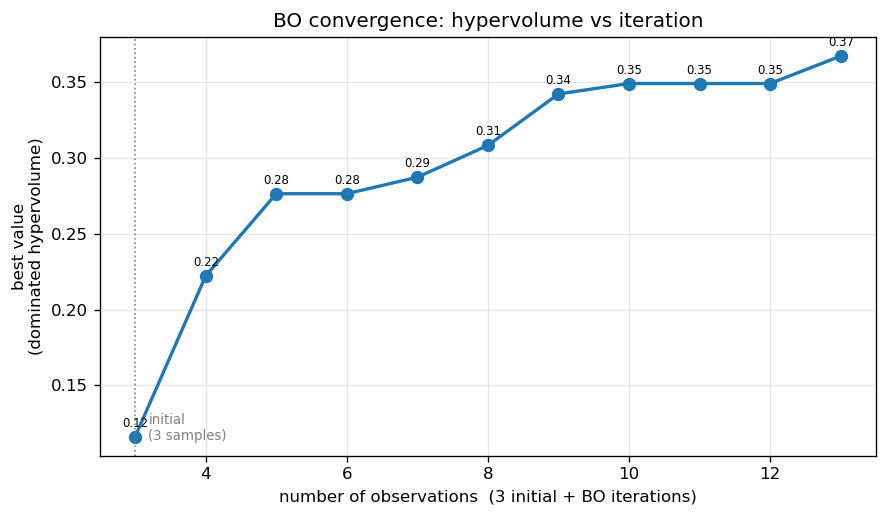

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(n_hist, hv_hist, 'o-', color='#1f77b4', lw=2, ms=7)
ax.axvline(n_hist[0], color='gray', ls=':', lw=1)
ax.annotate('initial\n(3 samples)', (n_hist[0], hv_hist[0]), fontsize=8, color='gray',
            xytext=(8, -2), textcoords='offset points')
for x, y in zip(n_hist, hv_hist):
    ax.annotate(f'{y:.2f}', (x, y), fontsize=7, xytext=(0, 6),
                textcoords='offset points', ha='center')
ax.set_xlabel('number of observations  (3 initial + BO iterations)')
ax.set_ylabel('best value\n(dominated hypervolume)')
ax.set_title('BO convergence: hypervolume vs iteration')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. How the lengthscale ℓ encodes a parameter's relevance & significance

The GP's RBF/ARD kernel between two inputs is

$$k(x,x') \;=\; \sigma^2 \exp\!\Big(\!-\tfrac12\sum_{j} \tfrac{(x_j-x'_j)^2}{\ell_j^2}\Big),$$

with **one lengthscale $\ell_j$ per factor** (Automatic Relevance Determination). $\ell_j$ is
the distance you must move along factor $j$ before the function "forgets" its current value:

* **small $\ell_j$** → the output decorrelates quickly → it *varies a lot* with factor $j$ → **relevant** (`relevance = 1/ℓ` is large);
* **large $\ell_j$** → the output stays correlated across the whole range → it is ~*flat* in factor $j$ → effectively **switched off**.

This section builds that intuition visually, then shows the difference between **relevance**
(how big is $1/\ell$) and **significance** (does the *data actually pin down* $\ell$, i.e. is
the marginal likelihood peaked in $\ell$).

### 8.1 The kernel: how correlation falls off with distance

$k$ as a function of the input distance $r=|x-x'|$ for several $\ell$. A short $\ell$ means
two points just a little apart are already nearly uncorrelated — the surrogate is allowed to
change fast, so it can "see" structure (relevance). A long $\ell$ keeps everything correlated,
forcing a flat fit.

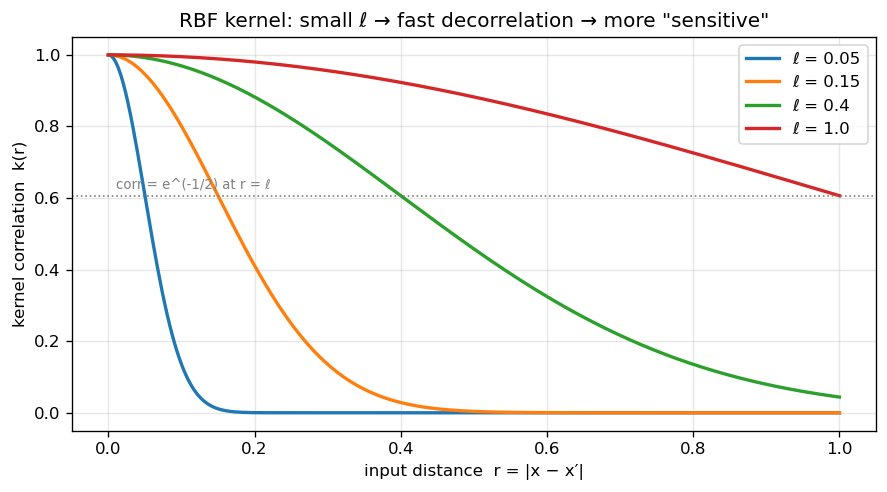

In [12]:
r = np.linspace(0, 1, 300)
ell_vals = [0.05, 0.15, 0.4, 1.0]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for l in ell_vals:
    ax.plot(r, np.exp(-r**2 / (2*l**2)), lw=2, label=f'ℓ = {l}')
ax.axhline(np.exp(-0.5), color='gray', ls=':', lw=1)
ax.text(0.01, np.exp(-0.5)+0.02, 'corr = e^(-1/2) at r = ℓ', fontsize=8, color='gray')
ax.set_xlabel('input distance  r = |x − x′|'); ax.set_ylabel('kernel correlation  k(r)')
ax.set_title('RBF kernel: small ℓ → fast decorrelation → more "sensitive"')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 8.2 What ℓ does to the functions the GP believes in (prior samples)

Drawing random functions from the GP *prior* for each $\ell$ shows it directly: small $\ell$
→ wiggly functions that can chase data (a factor that matters); large $\ell$ → nearly flat
functions (a factor the GP will treat as inactive).

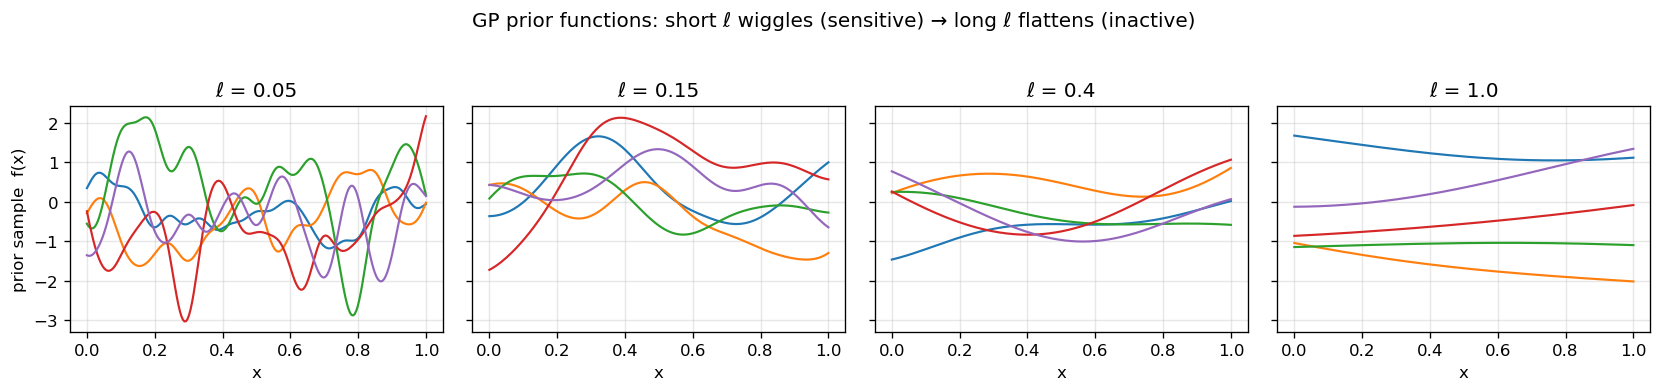

In [13]:
def rbf_cov(x, l):
    dist = x[:, None] - x[None, :]
    return np.exp(-dist**2 / (2*l**2))

xs = np.linspace(0, 1, 220)
rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, len(ell_vals), figsize=(14, 3.1), sharey=True)
for ax, l in zip(axes, ell_vals):
    L = np.linalg.cholesky(rbf_cov(xs, l) + 1e-9*np.eye(len(xs)))
    for _ in range(5):
        ax.plot(xs, L @ rng.normal(size=len(xs)), lw=1.3)
    ax.set_title(f'ℓ = {l}'); ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('prior sample  f(x)')
fig.suptitle('GP prior functions: short ℓ wiggles (sensitive) → long ℓ flattens (inactive)', y=1.04)
plt.tight_layout(); plt.show()

### 8.3 ARD on a 2-input test case: one factor matters, one doesn't

Cleanest possible demo. The ground truth depends on **x0 only**:
`f(x0, x1) = sin(3·x0)` — completely flat in **x1**. We fit a GP with ARD and let it discover
this. It should learn a **small ℓ for x0** and a **large ℓ for x1**, which `mobo.ard_sensitivity`
turns into a relevance bar. The slices make the mechanism obvious: steep along x0, flat along x1.

fitted lengthscales:  ℓ(x0) = 0.241   ℓ(x1) = 7.123
relevance (1/ℓ share): x0 = 0.967   x1 = 0.033


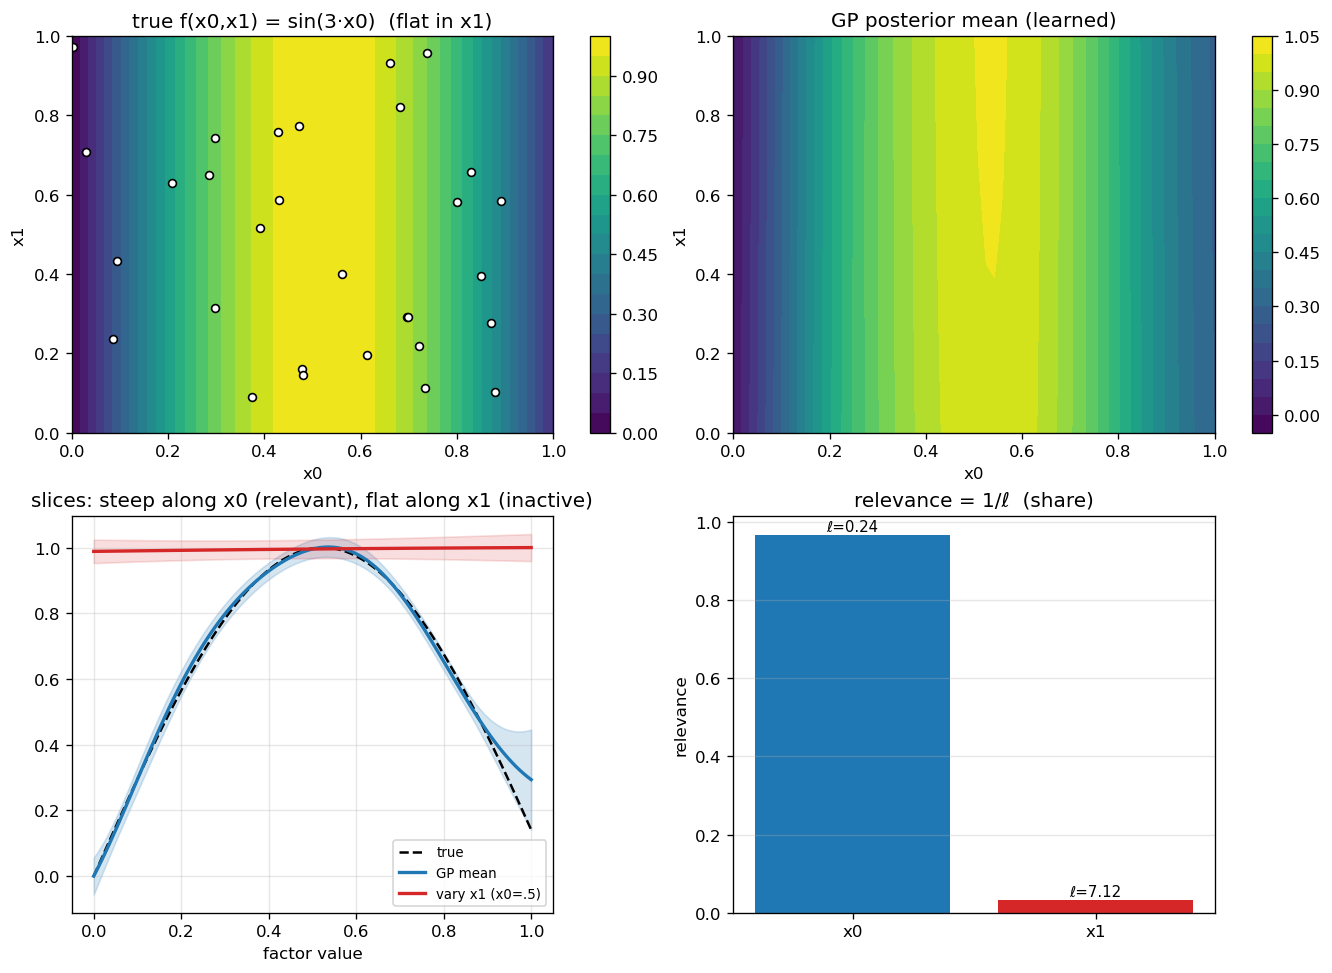

In [14]:
def f2d(x0, x1):                     # depends on x0 only  -> x1 is the "irrelevant" factor
    return np.sin(3.0 * x0)

rng = np.random.default_rng(3); n2 = 30
X2 = rng.random((n2, 2))
y2 = (f2d(X2[:, 0], X2[:, 1]) + 0.03*rng.normal(size=n2)).reshape(-1, 1)
gp2 = mobo.fit_gp(X2, y2)                                  # single-output GP with ARD
ell = gp2.covar_module.lengthscale.detach().numpy().ravel()
rel = mobo.ard_sensitivity(gp2, factor_names=['x0', 'x1'], output_names=['f'], normalize='sum')['f']
print(f'fitted lengthscales:  ℓ(x0) = {ell[0]:.3f}   ℓ(x1) = {ell[1]:.3f}')
print(f'relevance (1/ℓ share): x0 = {rel["x0"]:.3f}   x1 = {rel["x1"]:.3f}')

g = np.linspace(0, 1, 60); G0, G1 = np.meshgrid(g, g)
mu = gp2.posterior(torch.tensor(np.c_[G0.ravel(), G1.ravel()], **tkw)).mean.detach().numpy().reshape(G0.shape)
# slices through the centre
line = np.linspace(0, 1, 120)
sx0 = gp2.posterior(torch.tensor(np.c_[line, np.full_like(line, .5)], **tkw))
sx1 = gp2.posterior(torch.tensor(np.c_[np.full_like(line, .5), line], **tkw))
m0, s0 = sx0.mean.detach().numpy().ravel(), sx0.variance.sqrt().detach().numpy().ravel()
m1, s1 = sx1.mean.detach().numpy().ravel(), sx1.variance.sqrt().detach().numpy().ravel()

fig, ax = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
c0 = ax[0,0].contourf(G0, G1, f2d(G0, G1), 20, cmap='viridis')
ax[0,0].scatter(X2[:,0], X2[:,1], c='w', edgecolor='k', s=22)
ax[0,0].set_title('true f(x0,x1) = sin(3·x0)  (flat in x1)'); ax[0,0].set_xlabel('x0'); ax[0,0].set_ylabel('x1')
fig.colorbar(c0, ax=ax[0,0])
c1 = ax[0,1].contourf(G0, G1, mu, 20, cmap='viridis')
ax[0,1].set_title('GP posterior mean (learned)'); ax[0,1].set_xlabel('x0'); ax[0,1].set_ylabel('x1')
fig.colorbar(c1, ax=ax[0,1])
ax[1,0].plot(line, np.sin(3*line), 'k--', label='true')
ax[1,0].plot(line, m0, '#1f77b4', lw=2, label='GP mean')
ax[1,0].fill_between(line, m0-2*s0, m0+2*s0, color='#1f77b4', alpha=0.18)
ax[1,0].plot(line, m1, '#d62728', lw=2, label='vary x1 (x0=.5)')
ax[1,0].fill_between(line, m1-2*s1, m1+2*s1, color='#d62728', alpha=0.15)
ax[1,0].set_title('slices: steep along x0 (relevant), flat along x1 (inactive)')
ax[1,0].set_xlabel('factor value'); ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=0.3)
ax[1,1].bar(['x0', 'x1'], rel.values, color=['#1f77b4', '#d62728'])
for i, (l, rv) in enumerate(zip(ell, rel.values)):
    ax[1,1].text(i, rv+0.01, f'ℓ={l:.2f}', ha='center', fontsize=9)
ax[1,1].set_title('relevance = 1/ℓ  (share)'); ax[1,1].set_ylabel('relevance'); ax[1,1].grid(axis='y', alpha=0.3)
plt.show()

### 8.4 From *relevance* to *significance*: the marginal-likelihood profile

`1/ℓ` tells you how much the surrogate leans on a factor, but **is that supported by the
data?** The Bayesian answer is the **log marginal likelihood (LML)** as a function of $\ell_j$
(all other hyperparameters fixed at their fitted values):

* an **active** factor has a **sharp peak** at a finite $\ell$ — the data clearly prefers that
  value and penalizes both smaller and larger → *well-identified / significant*;
* an **inactive** factor has a **flat profile that just keeps rising as $\ell\to\infty$** — the
  data is indifferent and would happily switch the factor off → *not significant*.

The **curvature of the peak** is, loosely, the GP analogue of a standard error: a tight peak =
small uncertainty on $\ell$ = a confidently relevant factor.

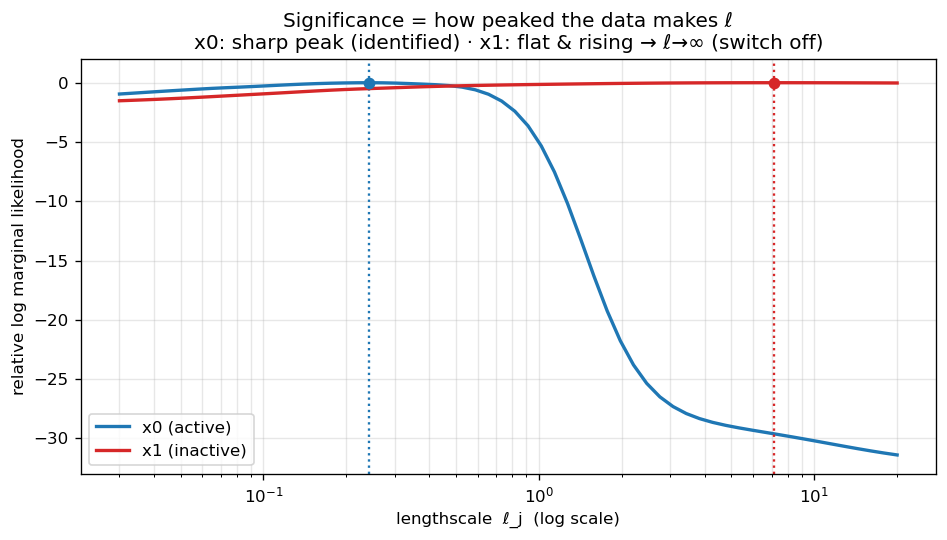

x0: LML loss if ℓ→20 (factor off):   -31.39 nats   -> SIGNIFICANT
x1: LML loss if ℓ→20 (factor off):    -0.02 nats   -> not significant


In [15]:
from gpytorch.mlls import ExactMarginalLogLikelihood

base = gp2.covar_module
ls0  = base.lengthscale.detach().clone()
mll  = ExactMarginalLogLikelihood(gp2.likelihood, gp2)
gp2.train()
def log_marg_like(j, val):                       # LML with ℓ_j set to `val`, others fixed
    ls = ls0.clone(); ls[..., j] = val; base.lengthscale = ls
    with torch.no_grad():
        return float(mll(gp2(*gp2.train_inputs), gp2.train_targets))

ell_grid = np.geomspace(0.03, 20, 60)
prof = np.array([[log_marg_like(j, v) for v in ell_grid] for j in range(2)])
base.lengthscale = ls0; gp2.eval()               # restore the fitted model

fig, ax = plt.subplots(figsize=(8, 4.6))
for j, (col, nm) in enumerate([('#1f77b4', 'x0 (active)'), ('#d62728', 'x1 (inactive)')]):
    ax.plot(ell_grid, prof[j] - prof[j].max(), color=col, lw=2, label=nm)
    ax.axvline(ell[j], color=col, ls=':', lw=1.4)
    ax.scatter([ell[j]], [0], color=col, zorder=5)
ax.set_xscale('log'); ax.set_ylim(top=2)
ax.set_xlabel('lengthscale  ℓ_j  (log scale)')
ax.set_ylabel('relative log marginal likelihood')
ax.set_title('Significance = how peaked the data makes ℓ\n'
             'x0: sharp peak (identified) · x1: flat & rising → ℓ→∞ (switch off)')
ax.legend(); ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()

# A crude "peakedness" score: how many nats the LML drops if ℓ is pushed to a large value
# (factor effectively removed). Big drop = the data insists on this factor = significant.
drop = prof[:, -1] - prof.max(axis=1)
for j, nm in enumerate(['x0', 'x1']):
    print(f'{nm}: LML loss if ℓ→{ell_grid[-1]:.0f} (factor off): {drop[j]:8.2f} nats'
          f'   -> {"SIGNIFICANT" if drop[j] < -2 else "not significant"}')

### 8.5 Interactive: drag ℓ and watch the kernel + the functions it allows

Run this cell live (it needs a running kernel) and move the slider: the left panel is the
kernel $k(r)$, the right panel are prior functions at that $\ell$. Sliding ℓ down makes the
admissible functions wigglier (the GP becomes "sensitive" to that factor); sliding it up
flattens them (the factor goes inactive). In a statically-rendered notebook you'll see the
initial frame; the slider is live only in a running kernel.

In [16]:
try:
    from ipywidgets import interact, FloatSlider

    def explore_ell(l=0.2):
        rr = np.linspace(0, 1, 200)
        fig, (axk, axf) = plt.subplots(1, 2, figsize=(11, 3.4))
        axk.plot(rr, np.exp(-rr**2 / (2*l**2)), color='#d62728', lw=2)
        axk.set_ylim(0, 1.02); axk.set_title(f'kernel k(r),  ℓ = {l:.2f}')
        axk.set_xlabel('r = |x − x′|'); axk.set_ylabel('correlation'); axk.grid(alpha=0.3)
        L = np.linalg.cholesky(rbf_cov(rr, l) + 1e-9*np.eye(len(rr)))
        g = np.random.default_rng(0)
        for _ in range(5):
            axf.plot(rr, L @ g.normal(size=len(rr)), lw=1.3)
        axf.set_ylim(-3, 3); axf.set_title('prior functions at this ℓ')
        axf.set_xlabel('x'); axf.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    interact(explore_ell, l=FloatSlider(min=0.03, max=1.5, step=0.01, value=0.2, description='ℓ'))
except Exception as e:
    print('Interactive slider needs ipywidgets + a live kernel:', e)

interactive(children=(FloatSlider(value=0.2, description='ℓ', max=1.5, min=0.03, step=0.01), Output()), _dom_c…

## How to read / reuse this

* **Cell 1 (Ground truth)** is the only thing to edit to test a different problem: change
  `f1_true` / `f2_true`, `NOISE_STD`, `N_COND`, `K_REPS`, or the factor `BOUNDS`. Everything
  downstream is generic `utils.mobo` and will follow.
* **Fit panel (§3)** shows the surrogate's mean/uncertainty per objective; **§3a** isolates
  the effect of feeding `y_var`.
* **§4** is the Pareto/hypervolume view the acquisition tries to grow; **§5** shows where the
  batch wants to sample next and *why* (the acquisition landscape), and **§5a** places those
  proposals back in objective space.
* **§6** is the animated 10-iteration loop starting from the 3 initial points (saved to
  `output/mobo_1d_test/mobo_1d_loop.gif`), and **§7** is the hypervolume-vs-iteration
  convergence curve (the multi-objective "best value").
* **§8** explains how the ARD lengthscale ℓ encodes parameter relevance (kernel shape, prior
  samples, a 2-input active/inactive test case) and how the **marginal-likelihood profile**
  separates *relevance* (`1/ℓ`) from *significance* (is ℓ actually pinned down by the data),
  with an interactive ℓ slider.
* This is the identical model + BO structure as the full 10-factor study — only the problem
  dimension and ground truth changed.